In [10]:
import pandas as pd
import numpy as np

data = pd.read_csv('Student_Marks.csv')
data.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [11]:
# Here we take time_study (independent variable) as X
X = np.array(data['time_study'])
# Here we take Marks as the target/dependent variable as Y
Y = np.array(data['Marks'])

In [12]:
n = len(X)

# ---- Linear Regression ----
m = (n*np.sum(X*Y) - np.sum(X)*np.sum(Y)) / (n*np.sum(X**2) - (np.sum(X))**2)
c = (np.sum(Y) - m*np.sum(X)) / n

print("Slope:", m)
print("Intercept:", c)
print(f"The Regression Equation is: Y_pred = {round(m,2)}*X + {round(c,2)}")

# Prediction
Y_pred = m*X + c

Slope: 5.688750421250445
Intercept: 1.2238581075029606
The Regression Equation is: Y_pred = 5.69*X + 1.22


In [13]:
def predict(x):
    return m * x + c

# Example
X_new = np.array([2, 4, 5, 6, 8])
y_pred_new = predict(X_new)
print("Predictions:", y_pred_new)

Predictions: [12.60135895 23.97885979 29.66761021 35.35636064 46.73386148]


In [17]:
for i in range(5):
    print(f"X: {X[i]}, Actual: {Y[i]}, Predicted: {predict(X[i])}")

X: 4.508, Actual: 19.202, Predicted: 26.868745006499964
X: 0.096, Actual: 7.734, Predicted: 1.7699781479430032
X: 3.133, Actual: 13.811, Predicted: 19.046713177280605
X: 7.909, Actual: 53.018, Predicted: 46.216185189172734
X: 7.811, Actual: 55.299, Predicted: 45.65868764789019


In [19]:
#Evaluation Metrics
mse = np.mean((Y - Y_pred)**2)
print("MSE:", mse)

ss_total = np.sum((Y - np.mean(Y))**2)
ss_residual = np.sum((Y - Y_pred)**2)

r2 = 1 - (ss_residual / ss_total)
print("R² Score:", r2)

MSE: 22.789030971957633
R² Score: 0.887842393906195


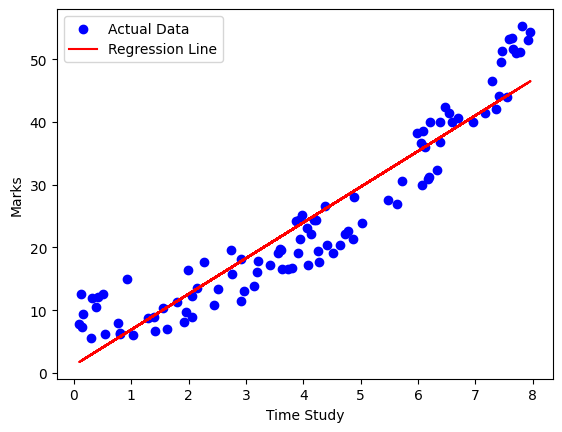

In [18]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', label='Regression Line')

plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.legend()
plt.show()

Slope (m): 5.355321531308333
Intercept (c): 2.5155655058073734
MSE: 25.23674562363223
R2 Score: 0.9040228286990537
New Predictions: [13.22620857 23.93685163 29.29217316 34.64749469 45.35813776]


C:\Users\user\Desktop\Post Grad\Post Graduation\Fergusson-College\Aritificial Intelligence\.myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\user\Desktop\Post Grad\Post Graduation\Fergusson-College\Aritificial Intelligence\.myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


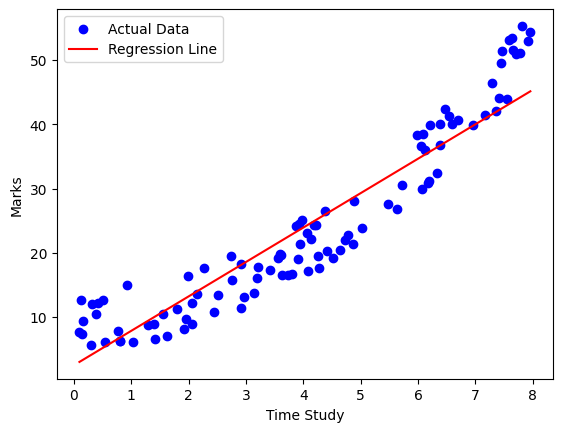

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = pd.read_csv("Student_Marks.csv")

# Features (X) and Target (Y)
X = data[['time_study']]   # must be 2D for sklearn
Y = data['Marks']

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, Y_train)

# Get parameters
m = model.coef_[0]
c = model.intercept_

print("Slope (m):", m)
print("Intercept (c):", c)

# Predictions on test data
Y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

# Predict new values
X_new = np.array([[2], [4], [5], [6], [8]])
Y_new_pred = model.predict(X_new)

print("New Predictions:", Y_new_pred)

# Visualization
plt.scatter(X, Y, color='blue', label='Actual Data')

# Sort for smooth line
X_sorted = np.sort(X.values, axis=0)
Y_sorted_pred = model.predict(X_sorted)

plt.plot(X_sorted, Y_sorted_pred, color='red', label='Regression Line')

plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.legend()
plt.show()